# 01 — Préparation des données

**Test Case Prioritization — Odoo 19.0**

Parse les logs/diffs des 30 commits, applique le *labeling souple* (score 0→1) et construit le dataset (features structurelles + TF-IDF).

**Entrée** : `data/final_data/` (logs+diffs), `data/odoo_dependencies.json`.  
**Sortie** : `artifacts/` (dataset.pkl, reverse_deps.pkl, idf.pkl, commits.pkl, generic.pkl).

In [1]:
# Chemins relatifs au package (portable)
from pathlib import Path
import os
ROOT = Path.cwd()
if ROOT.name == 'scripts':
    ROOT = ROOT.parent         
elif (ROOT / 'scripts').exists():
    pass                       
DATA = ROOT / 'data'
ARTIFACTS = ROOT / 'artifacts'
MODELS = ROOT / 'models'
ARTIFACTS.mkdir(exist_ok=True); MODELS.mkdir(exist_ok=True)
print('Racine du package :', ROOT)

Racine du package : c:\Users\LEGION\OneDrive\Bureau\package_evaluation


In [3]:
# ÉTAPE 0 : Imports
import subprocess, sys

import pandas as pd
import numpy as np
import os, re, warnings
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from datetime import datetime
from collections import Counter
from scipy.stats import spearmanr
warnings.filterwarnings('ignore')
np.random.seed(42)

In [4]:
# ── ÉTAPE 1 : Configuration des 30 commits ───────────────
BASE_PATH = str(DATA / 'final_data')

COMMITS = {
    'commit01': {'hash': '00a07d87a03e', 'date': '2025-09-03', 'modules_touched': ['account', 'purchase', 'sale'],
        'log': os.path.join(BASE_PATH, 'commit01_00a07d87_tests.log'),
        'diff': os.path.join(BASE_PATH, 'commit01_00a07d87_diff.txt')},
    'commit02': {'hash': '2e99e132e318', 'date': '2026-01-22', 'modules_touched': ['sale'],
        'log': os.path.join(BASE_PATH, 'commit02_2e99e132_tests.log'),
        'diff': os.path.join(BASE_PATH, 'commit02_2e99e132_diff.txt')},
    'commit03': {'hash': '2ad3f3bc85f2', 'date': '2026-02-03', 'modules_touched': ['point_of_sale'],
        'log': os.path.join(BASE_PATH, 'commit03_2ad3f3bc_tests.log'),
        'diff': os.path.join(BASE_PATH, 'commit03_2ad3f3bc_diff.txt')},
    'commit04': {'hash': 'ae1836391b96', 'date': '2026-02-05', 'modules_touched': ['mrp', 'sale_mrp'],
        'log': os.path.join(BASE_PATH, 'commit04_ae183639_tests.log'),
        'diff': os.path.join(BASE_PATH, 'commit04_ae183639_diff.txt')},
    'commit05': {'hash': '0f00c98b0e58', 'date': '2026-02-10', 'modules_touched': ['account'],
        'log': os.path.join(BASE_PATH, 'commit05_0f00c98b_tests.log'),
        'diff': os.path.join(BASE_PATH, 'commit05_0f00c98b_diff.txt')},
    'commit06': {'hash': '779aaf79c7e1', 'date': '2026-02-20', 'modules_touched': ['purchase'],
        'log': os.path.join(BASE_PATH, 'commit06_779aaf79_tests.log'),
        'diff': os.path.join(BASE_PATH, 'commit06_779aaf79_diff.txt')},
    'commit07': {'hash': 'ecb62ac0850a', 'date': '2026-02-24', 'modules_touched': ['purchase_stock', 'mrp'],
        'log': os.path.join(BASE_PATH, 'commit07_ecb62ac0_tests.log'),
        'diff': os.path.join(BASE_PATH, 'commit07_ecb62ac0_diff.txt')},
    'commit08': {'hash': '70361b3352e4', 'date': '2026-03-27', 'modules_touched': ['sale_stock', 'stock_account'],
        'log': os.path.join(BASE_PATH, 'commit08_70361b33_tests.log'),
        'diff': os.path.join(BASE_PATH, 'commit08_70361b33_diff.txt')},
    'commit09': {'hash': '10428c1ef573', 'date': '2026-03-05', 'modules_touched': ['sale_purchase_stock', 'sale_stock'],
        'log': os.path.join(BASE_PATH, 'commit09_10428c1e_tests.log'),
        'diff': os.path.join(BASE_PATH, 'commit09_10428c1e_diff.txt')},
    'commit10': {'hash': '967c24d9a59a', 'date': '2026-03-23', 'modules_touched': ['mrp'],
        'log': os.path.join(BASE_PATH, 'commit10_967c24d9_tests.log'),
        'diff': os.path.join(BASE_PATH, 'commit10_967c24d9_diff.txt')},
    'commit11': {'hash': 'f7f85f08f3a0', 'date': '2026-03-24', 'modules_touched': ['sale'],
        'log': os.path.join(BASE_PATH, 'commit11_f7f85f08f3a0_tests.log'),
        'diff': os.path.join(BASE_PATH, 'commit11_f7f85f08_diff.txt')},
    'commit12': {'hash': '8511114064b5', 'date': '2026-04-01', 'modules_touched': ['stock'],
        'log': os.path.join(BASE_PATH, 'commit12_8511114064b5_tests.log'),
        'diff': os.path.join(BASE_PATH, 'commit12_85111140_diff.txt')},
    'commit13': {'hash': 'e8d4ea2dc711', 'date': '2026-04-01', 'modules_touched': ['stock'],
        'log': os.path.join(BASE_PATH, 'commit13_e8d4ea2dc711_tests.log'),
        'diff': os.path.join(BASE_PATH, 'commit13_e8d4ea2d_diff.txt')},
    'commit14': {'hash': '50e898d3abc5', 'date': '2026-03-24', 'modules_touched': ['mrp'],
        'log': os.path.join(BASE_PATH, 'commit14_50e898d3abc5_tests.log'),
        'diff': os.path.join(BASE_PATH, 'commit14_50e898d3_diff.txt')},
    'commit15': {'hash': '3d850f26dcbe', 'date': '2026-04-28', 'modules_touched': ['hr_holidays'],
        'log': os.path.join(BASE_PATH, 'commit15_3d850f26_tests.log'),
        'diff': os.path.join(BASE_PATH, 'commit15_3d850f26_diff.txt')},
    'commit16': {'hash': 'fbdac503b6a9', 'date': '2026-04-20', 'modules_touched': ['account'],
        'log': os.path.join(BASE_PATH, 'commit16_fbdac503_tests.log'),
        'diff': os.path.join(BASE_PATH, 'commit16_fbdac503_diff.txt')},
    'commit17': {'hash': 'da82c1a69f5e', 'date': '2026-04-14', 'modules_touched': ['purchase'],
        'log': os.path.join(BASE_PATH, 'commit17_da82c1a6_tests.log'),
        'diff': os.path.join(BASE_PATH, 'commit17_da82c1a6_diff.txt')},
    'commit18': {'hash': '442cf8def562', 'date': '2026-04-22', 'modules_touched': ['account'],
        'log': os.path.join(BASE_PATH, 'commit18_442cf8de_tests.log'),
        'diff': os.path.join(BASE_PATH, 'commit18_442cf8de_diff.txt')},
    'commit19': {'hash': '63d813f0ffa4', 'date': '2026-03-23', 'modules_touched': ['point_of_sale'],
        'log': os.path.join(BASE_PATH, 'commit19_63d813f0_tests.log'),
        'diff': os.path.join(BASE_PATH, 'commit19_63d813f0_diff.txt')},
    'commit20': {'hash': '348e6698e225', 'date': '2026-04-02', 'modules_touched': ['stock'],
        'log': os.path.join(BASE_PATH, 'commit20_348e6698_tests.log'),
        'diff': os.path.join(BASE_PATH, 'commit20_348e6698_diff.txt')},
    'commit21': {'hash': 'ac72e930569f', 'date': '2026-04-28', 'modules_touched': ['account'],
        'log': os.path.join(BASE_PATH, 'commit21_ac72e930_tests.log'),
        'diff': os.path.join(BASE_PATH, 'commit21_ac72e930_diff.txt')},
    'commit22': {'hash': 'c3b9590fdfe5', 'date': '2026-04-28', 'modules_touched': ['account'],
        'log': os.path.join(BASE_PATH, 'commit22_c3b9590f_tests.log'),
        'diff': os.path.join(BASE_PATH, 'commit22_c3b9590f_diff.txt')},
    'commit23': {'hash': '5d58b75ff4ba', 'date': '2026-04-28', 'modules_touched': ['stock'],
        'log': os.path.join(BASE_PATH, 'commit23_5d58b75f_tests.log'),
        'diff': os.path.join(BASE_PATH, 'commit23_5d58b75f_diff.txt')},
    'commit24': {'hash': '03b8646d4b2d', 'date': '2026-04-28', 'modules_touched': ['stock'],
        'log': os.path.join(BASE_PATH, 'commit24_03b8646d_tests.log'),
        'diff': os.path.join(BASE_PATH, 'commit24_03b8646d_diff.txt')},
    'commit25': {'hash': '5be6062d7899', 'date': '2026-04-28', 'modules_touched': ['account'],
        'log': os.path.join(BASE_PATH, 'commit25_5be6062d_tests.log'),
        'diff': os.path.join(BASE_PATH, 'commit25_5be6062d_diff.txt')},
    'commit26': {'hash': '6f42cf7f777d', 'date': '2026-04-28', 'modules_touched': ['account'],
        'log': os.path.join(BASE_PATH, 'commit26_6f42cf7f_tests.log'),
        'diff': os.path.join(BASE_PATH, 'commit26_6f42cf7f_diff.txt')},
    'commit27': {'hash': 'eebe9b131a68', 'date': '2026-04-28', 'modules_touched': ['point_of_sale'],
        'log': os.path.join(BASE_PATH, 'commit27_eebe9b13_tests.log'),
        'diff': os.path.join(BASE_PATH, 'commit27_eebe9b13_diff.txt')},
    'commit28': {'hash': '4c855d81d20a', 'date': '2026-05-04', 'modules_touched': ['stock'],
        'log': os.path.join(BASE_PATH, 'commit28_4c855d81_tests.log'),
        'diff': os.path.join(BASE_PATH, 'commit28_4c855d81_diff.txt')},
    'commit29': {'hash': '7e324fa729b8', 'date': '2026-05-04', 'modules_touched': ['hr_holidays'],
        'log': os.path.join(BASE_PATH, 'commit29_7e324fa7_tests.log'),
        'diff': os.path.join(BASE_PATH, 'commit29_7e324fa7_diff.txt')},
    'commit30': {'hash': '58fe6a8803de', 'date': '2026-05-04', 'modules_touched': ['point_of_sale'],
        'log': os.path.join(BASE_PATH, 'commit30_58fe6a88_tests.log'),
        'diff': os.path.join(BASE_PATH, 'commit30_58fe6a88_diff.txt')},
}

for i, (cid, info) in enumerate(COMMITS.items(), 1):
    log_ok = os.path.exists(info['log'])
    diff_ok = os.path.exists(info['diff'])
    status = 'Ok' if log_ok and diff_ok else f"{'LOG_Error' if not log_ok else ''} {'DIFF_error' if not diff_ok else ''}"
    print(f"  {i:>2}. {info['date']} {info['hash'][:8]} {str(info['modules_touched']):<35} {status}")

   1. 2025-09-03 00a07d87 ['account', 'purchase', 'sale']     Ok
   2. 2026-01-22 2e99e132 ['sale']                            Ok
   3. 2026-02-03 2ad3f3bc ['point_of_sale']                   Ok
   4. 2026-02-05 ae183639 ['mrp', 'sale_mrp']                 Ok
   5. 2026-02-10 0f00c98b ['account']                         Ok
   6. 2026-02-20 779aaf79 ['purchase']                        Ok
   7. 2026-02-24 ecb62ac0 ['purchase_stock', 'mrp']           Ok
   8. 2026-03-27 70361b33 ['sale_stock', 'stock_account']     Ok
   9. 2026-03-05 10428c1e ['sale_purchase_stock', 'sale_stock'] Ok
  10. 2026-03-23 967c24d9 ['mrp']                             Ok
  11. 2026-03-24 f7f85f08 ['sale']                            Ok
  12. 2026-04-01 85111140 ['stock']                           Ok
  13. 2026-04-01 e8d4ea2d ['stock']                           Ok
  14. 2026-03-24 50e898d3 ['mrp']                             Ok
  15. 2026-04-28 3d850f26 ['hr_holidays']                     Ok
  16. 2026-04-20 fbdac5

In [5]:
# ÉTAPE 2 : Parseurs

# Détecte le début d'une nouvelle entrée de log (ligne commençant par une date AAAA-MM-JJ)
DATE_START = re.compile(r'^\d{4}-\d{2}-\d{2} ')

# Extrait les composants d'une ligne de log signalant le démarrage d'un test Odoo :
# timestamp, millisecondes, module, fichier de test, classe et méthode
PATTERN_START = re.compile(
    r'(\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}),(\d+)\s+\d+\s+\S+\s+\S+\s+'
    r'odoo\.addons\.(\w+)\.tests(?:\.\w+)*\.(\w+): Starting (\w+)\.(\w+)'
)


def read_file(path):
    """Lit un fichier texte en gérant automatiquement son encodage.

    Tente successivement UTF-16 (détecté via le BOM), UTF-8, puis Latin-1
    en dernier recours, afin de lire de manière robuste les logs et diffs
    pouvant provenir d'environnements et d'encodages hétérogènes.

    Args:
        path: Chemin du fichier à lire.

    Returns:
        Le contenu du fichier sous forme de chaîne, ou une chaîne vide
        si le chemin est invalide ou le fichier inexistant.
    """
    if not path or not os.path.exists(str(path)): return ''
    with open(path, 'rb') as f: raw = f.read()
    if raw[:2] == b'\xff\xfe': return raw.decode('utf-16', errors='replace')
    try: return raw.decode('utf-8', errors='replace')
    except: return raw.decode('latin-1', errors='replace')


def read_diff_for_embedding(path, max_chars=3000):
    """Lit un diff en tronquant son contenu pour l'encodage SBERT.

    La troncature limite la taille du texte transmis au modèle d'embedding,
    les premiers caractères du diff étant les plus représentatifs des
    modifications introduites.

    Args:
        path: Chemin du fichier de diff.
        max_chars: Nombre maximal de caractères conservés (défaut : 3000).

    Returns:
        Les premiers caractères du diff sous forme de chaîne.
    """
    return read_file(path)[:max_chars]


def merge_lines(raw_lines):
    """Reconstitue les entrées de log réparties sur plusieurs lignes.

    Les logs Odoo peuvent répartir une même entrée sur plusieurs lignes
    physiques. Cette fonction fusionne les lignes de continuation avec
    l'entrée précédente, une nouvelle entrée étant identifiée par un
    préfixe de date (voir DATE_START).

    Args:
        raw_lines: Liste des lignes brutes du fichier de log.

    Returns:
        Liste des entrées de log reconstituées, une par élément.
    """
    merged, current = [], ''
    for line in raw_lines:
        s = line.rstrip('\n').rstrip('\r')
        if DATE_START.match(s):
            if current: merged.append(current)
            current = s
        else:
            cont = s.strip()
            if cont:
                if current and not current.endswith(' '): current += ' '
                current += cont
    if current: merged.append(current)
    return merged


def parse_log(log_path):
    """Extrait la liste des tests exécutés à partir d'un log Odoo.

    Analyse le fichier de log pour identifier chaque test démarré, puis
    estime sa durée d'exécution comme l'écart de temps entre son démarrage
    et celui du test suivant. Cette durée est approximative et sert
    d'indicateur relatif (les logs pouvant refléter des exécutions
    partiellement parallélisées).

    Args:
        log_path: Chemin du fichier de log d'exécution des tests.

    Returns:
        Liste de dictionnaires, un par test, contenant le module, le nom
        de la classe, le nom de la méthode, le nom complet du test et sa
        durée estimée en millisecondes.
    """
    text = read_file(log_path)
    merged = merge_lines(text.split('\n'))
    starts = []
    for line in merged:
        m = PATTERN_START.search(line)
        if m:
            dt, ms, module, _, cls, method = m.groups()
            starts.append({'dt': f"{dt},{ms}", 'module': module,
                        'class': cls, 'method': method})
    rows = []
    for i, t in enumerate(starts):
        try:
            dt0 = datetime.strptime(t['dt'], '%Y-%m-%d %H:%M:%S,%f')
            dt1 = datetime.strptime(starts[i+1]['dt'], '%Y-%m-%d %H:%M:%S,%f') if i+1<len(starts) else dt0
            dur = max(0, int((dt1-dt0).total_seconds()*1000))
        except: dur = 0
        rows.append({'module': t['module'], 'class_name': t['class'],
                    'method_name': t['method'],
                    'test_name': f"{t['class']}.{t['method']}",
                    'duration_ms': dur})
    return rows


def parse_diff(diff_text):
    """Extrait les métadonnées structurelles et lexicales d'un diff Git.

    Analyse le contenu d'un diff pour en dériver les informations
    exploitées par le pipeline de features : fichiers modifiés (en
    distinguant fichiers de test et fichiers de code), fonctions et
    classes touchées, mots-clés significatifs des lignes modifiées,
    modules concernés, tokens des noms de fichiers, ainsi que des
    statistiques de volume (lignes ajoutées/supprimées).

    Args:
        diff_text: Contenu textuel du diff Git.

    Returns:
        Dictionnaire regroupant les fichiers, fichiers de test, fichiers
        de code, fonctions, classes, mots-clés, modules du diff, tokens de
        noms de fichiers, nombre de fichiers, lignes ajoutées, lignes
        supprimées et type dominant du diff.
    """
    files = re.findall(r'diff --git a/(.+?) b/', diff_text)
    added = len([l for l in diff_text.split('\n') if l.startswith('+') and not l.startswith('+++')])
    deleted = len([l for l in diff_text.split('\n') if l.startswith('-') and not l.startswith('---')])
    test_files = [f for f in files if '/tests/' in f]
    code_files = [f for f in files if '/tests/' not in f]
    functions = set(re.findall(r'def (\w+)', diff_text))
    classes = set(re.findall(r'class (\w+)', diff_text))

    # Collecte les mots-clés significatifs (> 4 caractères) des lignes ajoutées ou supprimées
    keywords = set()
    for line in diff_text.split('\n'):
        if (line.startswith('+') and not line.startswith('+++')) or \
        (line.startswith('-') and not line.startswith('---')):
            tokens = re.findall(r'[a-z_][a-z_0-9]+', line.lower())
            keywords.update(t for t in tokens if len(t) > 4)

    # Identifie les modules Odoo concernés à partir du chemin addons/<module>/...
    diff_modules = set()
    for f in files:
        parts = f.split('/')
        if len(parts) >= 2 and parts[0] == 'addons':
            diff_modules.add(parts[1])

    # Extrait les tokens des noms de fichiers modifiés (après retrait de l'extension)
    filename_tokens = set()
    for f in files:
        basename = f.split('/')[-1]
        for ext in ['.py', '.xml', '.js', '.scss', '.ts']:
            basename = basename.replace(ext, '')
        tokens = [t for t in basename.split('_') if len(t) > 3]
        filename_tokens.update(tokens)

    # Détermine le type dominant du diff selon l'extension la plus fréquente
    exts = Counter([f.split('.')[-1] for f in files if '.' in f])
    dom = exts.most_common(1)[0][0] if exts else 'unknown'
    dtype = {'py':'python','xml':'xml','js':'javascript'}.get(dom, dom)
    return {
        'files': files, 'test_files': test_files, 'code_files': code_files,
        'functions': functions, 'classes': classes, 'keywords': keywords,
        'diff_modules': diff_modules, 'filename_tokens': filename_tokens,
        'nb_files': len(files), 'lines_added': added, 'lines_deleted': deleted,
        'diff_type': dtype,
    }


In [6]:
#ÉTAPE 2b : Graphe de dépendances Odoo
import json

with open(DATA / 'final_data' / 'odoo_dependencies.json') as f:
    raw_deps = json.load(f)

def get_dependents(module, deps_graph, depth=1):
    """Retourne les modules qui dépendent du module donné (dépendances inverses).

    Parcourt le graphe pour identifier tous les modules déclarant 'module'
    parmi leurs dépendances. Le paramètre 'depth' permet de remonter la chaîne
    de manière transitive : depth=1 ne retient que les dépendants directs,
    tandis qu'une profondeur supérieure inclut récursivement les dépendants
    indirects (les modules qui dépendent des dépendants, etc.).

    Args:
        module: Nom du module dont on cherche les dépendants.
        deps_graph: Graphe de dépendances {module: [dépendances]}.
        depth: Profondeur de remontée transitive (défaut : 1, direct seulement).

    Returns:
        Ensemble des noms de modules dépendant du module donné.
    """
    
    dependents = set()
    for mod, mod_deps in deps_graph.items():
        if module in mod_deps:
            dependents.add(mod)
            if depth > 1:
                dependents |= get_dependents(mod, deps_graph, depth-1)
    return dependents

# Dictionnaire inverse : module → qui dépend de lui (depth=1 = direct seulement)
reverse_deps = {mod: get_dependents(mod, raw_deps, depth=1) for mod in raw_deps}

print(f" Graphe chargé : {len(raw_deps)} modules")
print(f"\ndépendences :")
for mod in ['account', 'stock', 'mrp', 'sale', 'purchase', 'point_of_sale']:
    deps = list(reverse_deps.get(mod, set()))[:6]
    n = len(reverse_deps.get(mod, set()))
    print(f"  {mod:<20} : {n} modules : {deps}")

 Graphe chargé : 617 modules

dépendences :
  account              : 151 modules : ['l10n_co', 'base_vat', 'l10n_eu_oss', 'l10n_syscohada', 'l10n_cn', 'l10n_tw']
  stock                : 11 modules : ['mrp', 'project_stock', 'l10n_din5008_stock', 'l10n_ec_stock', 'stock_sms', 'stock_account']
  mrp                  : 9 modules : ['sale_mrp', 'mrp_repair', 'purchase_mrp', 'mrp_product_expiry', 'mrp_account', 'mrp_subcontracting']
  sale                 : 21 modules : ['l10n_ec_sale', 'l10n_br_sales', 'spreadsheet_dashboard_sale', 'l10n_in_sale', 'sale_sms', 'sale_product_matrix']
  purchase             : 7 modules : ['purchase_requisition', 'l10n_din5008_purchase', 'sale_purchase', 'purchase_stock', 'purchase_product_matrix', 'project_purchase']
  point_of_sale        : 42 modules : ['pos_razorpay', 'l10n_fr_pos_cert', 'l10n_in_pos', 'pos_mercado_pago', 'pos_hr', 'l10n_mt_pos']


In [7]:
# ÉTAPE 3 : Labeling souple (score continu 0 --> 1)

def compute_relevance_score(test_name, class_name, method_name, module,
                            diff_info, generic_words=None, generic_funcs=None):
    """Attribue un score continu de pertinence à une paire commit-test.

    Implémente le labeling souple : plutôt qu'une étiquette binaire, chaque
    test reçoit un score dans [0, 1] reflétant son degré de proximité avec les
    modifications du commit. Les règles sont évaluées du signal le plus fort
    au plus faible, et le score retenu est le plus élevé déclenché. Les signaux
    directs (test présent dans le diff, même classe modifiée) court-circuitent
    l'évaluation et retournent immédiatement.

    Hiérarchie des scores :
        1.0  -- la méthode de test apparaît explicitement dans le diff ;
        0.8  -- le test appartient à une classe d'un fichier de test modifié ;
        0.5-0.6 -- une fonction spécifique modifiée est partagée avec le test ;
        0.3-0.4 -- des mots-clés significatifs sont partagés (lexical) ;
        0.2  -- le test appartient à un module directement modifié ;
        0.1  -- le test appartient à un module dépendant d'un module touché ;
        0.0  -- aucun lien identifié.

    Args:
        test_name: Nom complet du test (classe.méthode).
        class_name: Nom de la classe de test.
        method_name: Nom de la méthode de test.
        module: Module Odoo auquel appartient le test.
        diff_info: Métadonnées du diff (issues de parse_diff).
        generic_words: Mots génériques à exclure du matching lexical
            (filtrage de type TF-IDF). Valeur par défaut si non fourni.
        generic_funcs: Fonctions génériques à ignorer (ex. utilitaires
            communs) pour éviter les faux positifs.

    Returns:
        Tuple (score, raisons) où score est arrondi à deux décimales et
        raisons est une chaîne décrivant les règles déclenchées (pour
        l'inspection et le débogage du labeling).
    """
    score = 0.0
    reasons = []
    mn_lower = method_name.lower()
    cn_lower = class_name.lower()

    # 1.0 : la méthode de test elle-même apparaît dans le diff (signal le plus fort)
    for func in diff_info['functions']:
        if func.startswith('test_') and func == method_name:
            return 1.0, 'test_in_diff'

    # 0.8 : le test appartient à une classe présente dans un fichier de test modifié
    # (repli à 0.5 si le fichier de test est touché mais pas la classe exacte)
    for f in diff_info['test_files']:
        parts = f.split('/')
        if len(parts) >= 4 and parts[2] == 'tests' and parts[1] == module:
            if class_name in diff_info['classes']:
                return 0.8, f'same_class:{class_name}'
            score = max(score, 0.5)
            reasons.append(f'same_test_file:{f.split("/")[-1]}')

    # 0.5-0.6 : une fonction spécifique (non générique) modifiée est liée au test,
    # soit par inclusion directe de son nom, soit par recouvrement lexical (>= 2 termes)
    gfuncs = generic_funcs if generic_funcs else set()
    for func in diff_info['functions']:
        fl = func.lower()
        if fl in gfuncs or func.startswith('test_'): continue
        # Nom de fonction long inclus tel quel dans le nom du test -> signal fort (0.6)
        if len(fl) > 8 and fl in f"{cn_lower}.{mn_lower}":
            score = max(score, 0.6)
            reasons.append(f'func:{func}')
            break
        # Sinon, recouvrement d'au moins deux composants lexicaux significatifs (0.5)
        func_parts = set(fl.split('_')) - {'','get','set','compute','to','at','in','of','the','is','a','and','or'}
        test_parts = set(mn_lower.split('_')) - {'','test','self'}
        overlap = func_parts & test_parts
        if len(overlap) >= 2 and len(func_parts) >= 2:
            score = max(score, 0.5)
            reasons.append(f'overlap:{overlap}')
            break

    # 0.3-0.4 : mots-clés partagés entre le diff et le nom du test, après
    # exclusion des mots génériques (3+ mots -> 0.4, exactement 2 -> 0.3)
    if score < 0.4:
        stop = generic_words if generic_words else {
            'self','true','false','none','return','assert','line',
            'model','name','value','data','super','context','test'
        }
        diff_kw = diff_info['keywords'] - stop
        test_kw = set(re.findall(r'[a-z_][a-z_0-9]+',
                    f"{cn_lower}_{mn_lower}")) - stop
        shared = diff_kw & test_kw
        if len(shared) >= 3:
            score = max(score, 0.4)
            reasons.append(f'kw3+:{list(shared)[:4]}')
        elif len(shared) >= 2:
            score = max(score, 0.3)
            reasons.append(f'kw2:{list(shared)}')

    # 0.2 : le test appartient à un module directement modifié par le commit
    if score < 0.2 and module in diff_info.get('diff_modules', set()):
        score = max(score, 0.2)
        reasons.append(f'module:{module}')

    # 0.1 : le test appartient à un module qui dépend d'un module touché
    # (lien structurel indirect via le graphe de dépendances inverses)
    if score < 0.15:
        for touched_mod in diff_info.get('diff_modules', set()):
            if module in reverse_deps.get(touched_mod, set()):
                score = max(score, 0.10)
                reasons.append(f'depends_on:{touched_mod}')
                break

    return round(score, 2), '|'.join(reasons) if reasons else 'none'

In [8]:
# ÉTAPE 4 : Construction du dataset 

# 4a : Calcul TF-IDF  
import math
print("Calcul TF-IDF inversé (version correcte)...")

# Fréquence des mots dans les DIFFS (pas dans les tests)
word_in_diffs = Counter()
func_in_diffs = Counter()
for cid, info in COMMITS.items():
    diff_text = read_file(info['diff'])
    diff_words = set(re.findall(r'[a-z][a-z_0-9]+', diff_text.lower()))
    diff_funcs = set(re.findall(r'def (\w+)', diff_text))
    word_in_diffs.update(diff_words)
    func_in_diffs.update(diff_funcs)

# IDF = log(nb_commits / nb_commits_avec_le_mot)
N = len(COMMITS)
IDF = {word: math.log(N / count) for word, count in word_in_diffs.items()}
GENERIC_FUNCS = {f for f, c in func_in_diffs.items() if c / N > 0.40}

print(f"  Vocabulaire des diffs : {len(IDF)} mots")
print(f"  Fonctions génériques (>40%) : {len(GENERIC_FUNCS)}")

# Top 10 mots les MOINS discriminants (IDF faible = génériques)
least_disc = sorted(IDF.items(), key=lambda x: x[1])[:10]
print(f"  Mots les moins discriminants : {[w for w,_ in least_disc]}")

# Top 10 mots les PLUS discriminants (IDF élevé = spécifiques)
most_disc = sorted(IDF.items(), key=lambda x: -x[1])[:10]
print(f"  Mots les plus discriminants  : {[w for w,_ in most_disc]}")

# GENERIC_WORDS reste pour filter les mots trop courts ou syntaxiques
GENERIC_WORDS = {
    'def', 'class', 'import', 'return', 'true', 'false', 'none',
    'self', 'super', 'pass', 'raise', 'yield', 'with', 'from',
    'test', 'tests'
}

# ── 4b : Construction des rows ──
all_rows = []
diff_infos = {}

for cid, info in COMMITS.items():
    if not os.path.exists(info['log']):
        print(f"{cid}: log manquant"); continue

    tests = parse_log(info['log'])
    diff_text = read_file(info['diff'])
    di = parse_diff(diff_text)
    diff_infos[info['hash']] = di

    # Mots du diff courant (pour TF-IDF)
    diff_words_commit = set(re.findall(r'[a-z][a-z_0-9]+', diff_text.lower())) - GENERIC_WORDS
    touched_mods = di.get('diff_modules', set())

    scores = []
    for t in tests:
        rel_score, reason = compute_relevance_score(
            t['test_name'], t['class_name'], t['method_name'],
            t['module'], di,
            generic_words=GENERIC_WORDS,
            generic_funcs=GENERIC_FUNCS)
        scores.append(rel_score)

        # Mots du nom du test
        test_tokens = set(re.findall(r'[a-z][a-z_0-9]+', t['test_name'].lower()))
        test_words = test_tokens - GENERIC_WORDS

        # TF-IDF 
        # Mots partagés entre le diff courant et le nom du test
        shared_tfidf = test_words & diff_words_commit
        # Score = somme des IDF → mots rares dans les diffs = score élevé
        tfidf_score = sum(IDF.get(w, 0) for w in shared_tfidf)
        tfidf_count = len(shared_tfidf)

        # ── filename_kw ──
        fname_overlap = (di.get('filename_tokens', set()) & test_tokens) - GENERIC_WORDS

        # ── test_file_touched ──
        test_file_touched = int(
            any(t['class_name'].lower() in f.lower()
                for f in di.get('test_files', [])))

        # ── module_dependency_touched ──
        is_dep = any(t['module'] in reverse_deps.get(tm, set()) for tm in touched_mods)

        row = {
            'commit_id': cid, 'commit_hash': info['hash'],
            'commit_date': info['date'],
            'module': t['module'], 'class_name': t['class_name'],
            'method_name': t['method_name'], 'test_name': t['test_name'],
            'full_test_id': f"{t['module']}.{t['test_name']}",
            # Git/Diff
            'module_touched': int(t['module'] in info['modules_touched']),
            'module_dependency_touched': int(is_dep),
            'test_file_touched': test_file_touched,
            'commit_nb_files': di['nb_files'],
            'commit_lines_added': di['lines_added'],
            'commit_lines_deleted': di['lines_deleted'],
            'commit_lines_total': di['lines_added'] + di['lines_deleted'],
            # Test
            'duration_ms': t['duration_ms'],
            'is_slow_test': int(t['duration_ms'] > 1000),
            'test_name_length': len(t['test_name']),
            'method_name_length': len(t['method_name']),
            # Filename keywords
            'filename_kw_count': len(fname_overlap),
            'has_filename_kw': int(len(fname_overlap) > 0),
            # TF-IDF
            'tfidf_score': tfidf_score,
            'tfidf_count': tfidf_count,
            'has_tfidf_kw': int(tfidf_count > 0),
            # Labels
            'relevance_score': rel_score,
            'label_relevant': int(rel_score >= 0.5),
            'relevance_reason': reason,
        }
        all_rows.append(row)

    n_pos = sum(1 for s in scores if s >= 0.5)
    n_partial = sum(1 for s in scores if 0 < s < 0.5)
    n_dep = sum(1 for t in tests
                if any(t['module'] in reverse_deps.get(tm, set()) for tm in touched_mods))
    print(f"  {cid} ({info['date']}) : {len(tests):,} tests | "
          f"pertinents: {n_pos} | partiels: {n_partial} | "
          f"deps: {n_dep} | diff_words: {len(diff_words_commit)}")

df = pd.DataFrame(all_rows)
print(f"\n taille du  Dataset : {len(df):,} lignes × {len(df.columns)} colonnes")
print(f"   Score >= 0.5              : {df.label_relevant.sum():,} ({df.label_relevant.mean()*100:.1f}%)")
print(f"   module_dep_touched > 0    : {df.module_dependency_touched.sum():,} ({df.module_dependency_touched.mean()*100:.1f}%)")
print(f"   tfidf_score > 0           : {(df.tfidf_score > 0).sum():,} ({(df.tfidf_score > 0).mean()*100:.1f}%)")
print(f"   tfidf_score moyen         : {df.tfidf_score.mean():.4f}")
print(f"   tfidf_score moyen (pert.) : {df[df.label_relevant==1].tfidf_score.mean():.4f}")
print(f"   tfidf_score moyen (non p.): {df[df.label_relevant==0].tfidf_score.mean():.4f}")



Calcul TF-IDF inversé (version correcte)...
  Vocabulaire des diffs : 1663 mots
  Fonctions génériques (>40%) : 0
  Mots les moins discriminants : ['diff', 'git', 'addons', 'index', 'py', 'models', 'class', 'self', 'model', 'def']
  Mots les plus discriminants  : ['test_accrued_purchase_orders', 'compute_move_vals', 'test_accrued_sale_orders', 'expense_account', 'dd61749b03c1', 'b41919b', 'qty_received_at_date', 'into', 'alt_inc_account', 'total_void']
  commit01 (2025-09-03) : 8,744 tests | pertinents: 392 | partiels: 2106 | deps: 1267 | diff_words: 180
  commit02 (2026-01-22) : 8,768 tests | pertinents: 229 | partiels: 547 | deps: 547 | diff_words: 110
  commit03 (2026-02-03) : 8,616 tests | pertinents: 447 | partiels: 174 | deps: 174 | diff_words: 140
  commit04 (2026-02-05) : 8,723 tests | pertinents: 69 | partiels: 472 | deps: 151 | diff_words: 140
  commit05 (2026-02-10) : 8,610 tests | pertinents: 1036 | partiels: 438 | deps: 501 | diff_words: 243
  commit06 (2026-02-20) : 8,614

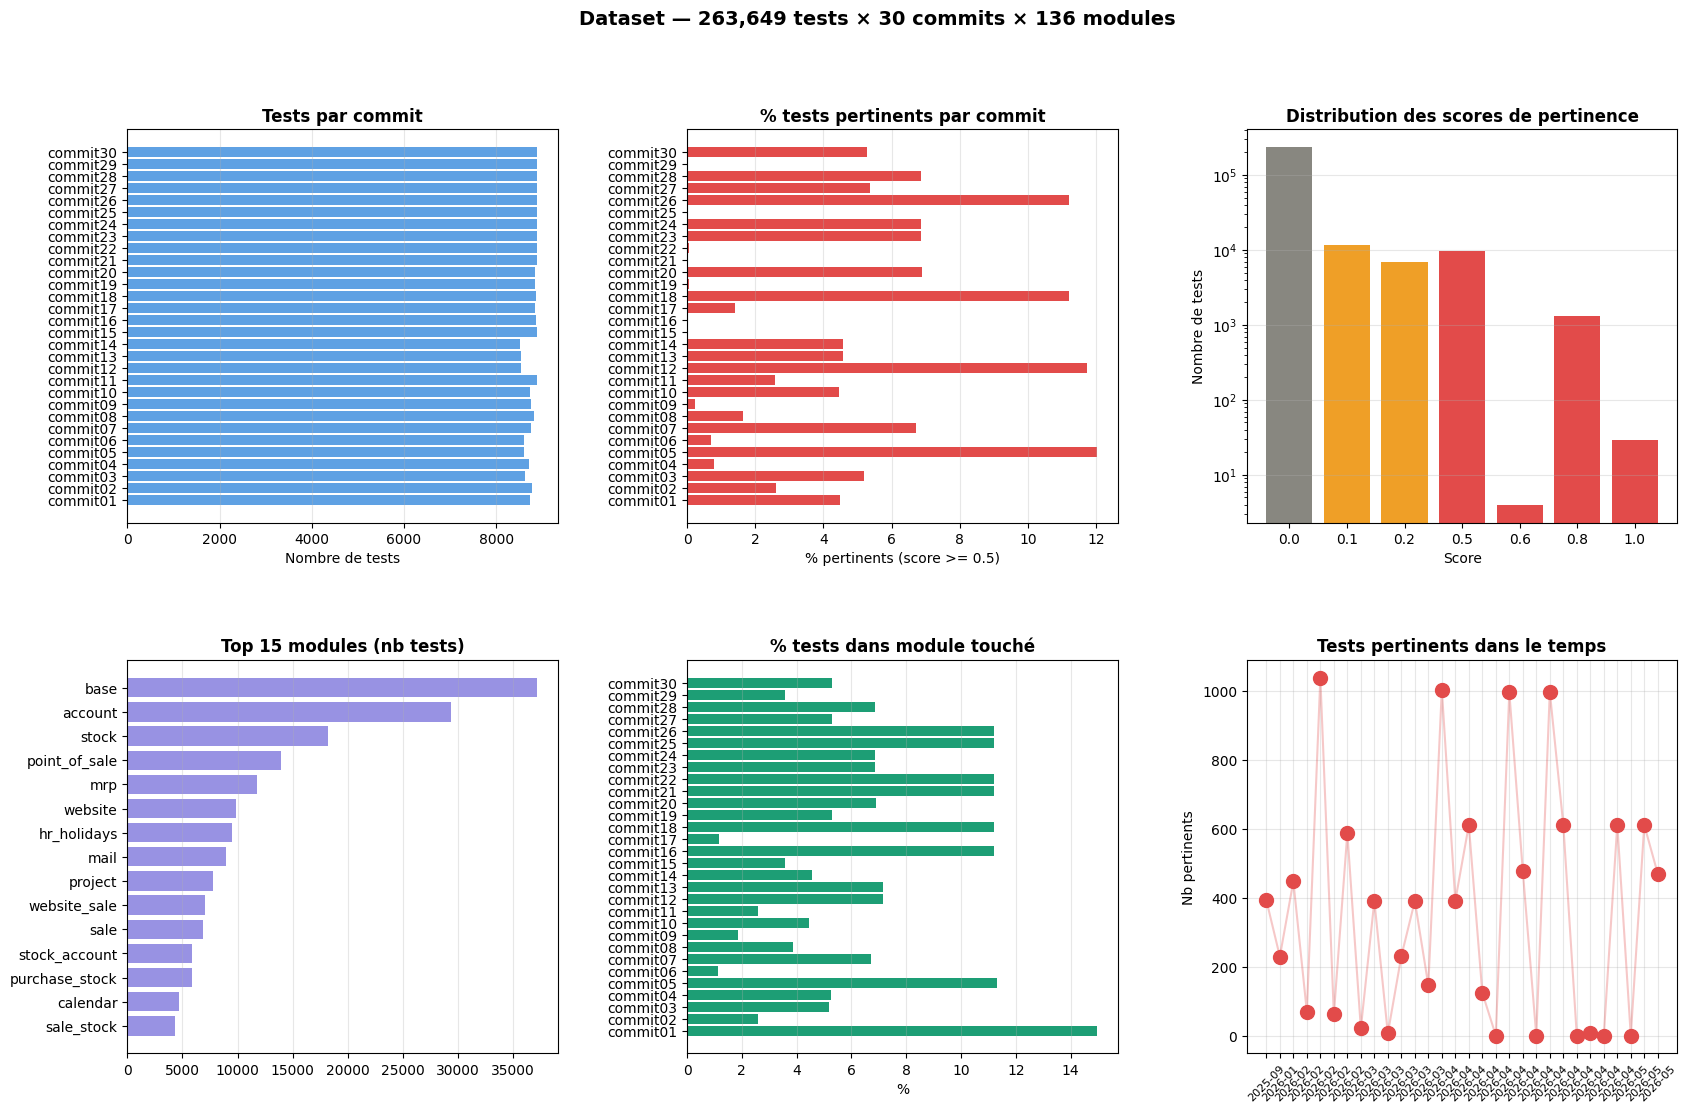

In [12]:
# ── ÉTAPE 5 : Visualisation du dataset ────────────────────
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(2, 3, hspace=0.35, wspace=0.3)

# 1. Tests par commit
ax1 = fig.add_subplot(gs[0, 0])
commit_sizes = df.groupby('commit_id').size()
ax1.barh(commit_sizes.index, commit_sizes.values, color='#378ADD', alpha=0.8)
ax1.set_title('Tests par commit', fontweight='bold')
ax1.set_xlabel('Nombre de tests')
ax1.grid(axis='x', alpha=0.3)

# 2. % pertinents par commit
ax2 = fig.add_subplot(gs[0, 1])
pct_per_commit = df.groupby('commit_id')['label_relevant'].mean() * 100
colors_pct = ['#E24B4A' if p > 0 else '#888780' for p in pct_per_commit]
ax2.barh(pct_per_commit.index, pct_per_commit.values, color=colors_pct)
ax2.set_title('% tests pertinents par commit', fontweight='bold')
ax2.set_xlabel('% pertinents (score >= 0.5)')
ax2.grid(axis='x', alpha=0.3)

# 3. Distribution des scores
ax3 = fig.add_subplot(gs[0, 2])
score_counts = df.relevance_score.value_counts().sort_index()
colors_sc = ['#888780' if s == 0 else '#EF9F27' if s < 0.5 else '#E24B4A' for s in score_counts.index]
ax3.bar([f'{s:.1f}' for s in score_counts.index], score_counts.values, color=colors_sc)
ax3.set_title('Distribution des scores de pertinence', fontweight='bold')
ax3.set_xlabel('Score'); ax3.set_ylabel('Nombre de tests')
ax3.set_yscale('log')
ax3.grid(axis='y', alpha=0.3)

# 4. Top 15 modules
ax4 = fig.add_subplot(gs[1, 0])
top_mods = df.groupby('module').size().sort_values(ascending=True).tail(15)
ax4.barh(top_mods.index, top_mods.values, color='#7F77DD', alpha=0.8)
ax4.set_title('Top 15 modules (nb tests)', fontweight='bold')
ax4.grid(axis='x', alpha=0.3)

# 5. Modules touchés par commit
ax5 = fig.add_subplot(gs[1, 1])
touched = df.groupby('commit_id')['module_touched'].mean() * 100
ax5.barh(touched.index, touched.values, color='#1D9E75')
ax5.set_title('% tests dans module touché', fontweight='bold')
ax5.set_xlabel('%')
ax5.grid(axis='x', alpha=0.3)

# 6. Timeline
ax6 = fig.add_subplot(gs[1, 2])
dates = df.groupby('commit_id')['commit_date'].first().sort_values()
sizes = df.groupby('commit_id')['label_relevant'].sum()
ax6.scatter(range(len(dates)), [sizes[c] for c in dates.index], 
            s=100, c='#E24B4A', zorder=5)
ax6.plot(range(len(dates)), [sizes[c] for c in dates.index], 
         color='#E24B4A', alpha=0.3)
ax6.set_xticks(range(len(dates)))
ax6.set_xticklabels([d[:7] for d in dates.values], rotation=45, fontsize=8)
ax6.set_title('Tests pertinents dans le temps', fontweight='bold')
ax6.set_ylabel('Nb pertinents')
ax6.grid(alpha=0.3)

plt.suptitle(f'Dataset — {len(df):,} tests × {df.commit_id.nunique()} commits × {df.module.nunique()} modules',
             fontsize=14, fontweight='bold')
plt.savefig(os.path.join(BASE_PATH, 'v5_dataset_overview.png'), dpi=150, bbox_inches='tight')
plt.show()

## Sauvegarde des artefacts

In [12]:
import pickle
df.to_pickle(ARTIFACTS/'dataset.pkl')
pickle.dump(reverse_deps, open(ARTIFACTS/'reverse_deps.pkl','wb'))
pickle.dump({'IDF':IDF,'GENERIC_FUNCS':GENERIC_FUNCS}, open(ARTIFACTS/'idf.pkl','wb'))
pickle.dump(COMMITS, open(ARTIFACTS/'commits.pkl','wb'))
pickle.dump(GENERIC_WORDS, open(ARTIFACTS/'generic.pkl','wb'))
print('Artefacts 01 sauvegardés dans', ARTIFACTS)

Artefacts 01 sauvegardés dans c:\Users\LEGION\OneDrive\Bureau\package_evaluation\artifacts
